# Phase 8: Hyperparameter Tuning

For every model we evaluate a **compact grid of configurations** under one shared
**5-fold Stratified CV** on the unified cleaned train set, then promote the
**best configuration (by ROC-AUC)** into a single leaderboard. This makes the
final comparison a fair race between each model *at its best*.

- One cell per model. Each prints a per-config table and records the winner.
- Same protocol as Phases 2/6/7: `StratifiedKFold(5, shuffle, random_state=42)`,
  metrics Accuracy / F1 / ROC-AUC.
- Outputs: `tuning_results.csv`, `leaderboard_table.tex`,
  `figures/fig_tuning_panel.png`, `figures/fig_loss_gbdt.png`,
  `figures/fig_loss_tabm.png`.

In [1]:
# Run once if a package is missing:
# %pip install xgboost lightgbm catboost torch tabpfn scikit-learn matplotlib python-dotenv

In [2]:
import time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import lightgbm as lgb
from catboost import CatBoostClassifier

warnings.filterwarnings("ignore")
SEED = 42

# ---- data (same cleaned set used everywhere; path works from repo root or notebooks/)
DATA = Path("../data/processed")
if not DATA.exists():
    DATA = Path("data/processed")
FIG = Path("../figures")
if not FIG.exists():
    FIG = Path("figures")
FIG.mkdir(exist_ok=True)

train = pd.read_csv(DATA / "train_cleaned.csv")
TARGET = "Class/ASD"
X = train.drop(columns=[TARGET]).values.astype(np.float32)
y = train[TARGET].values.astype(np.int64)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
spw = (y == 0).sum() / (y == 1).sum()           # scale_pos_weight for XGBoost
print(f"train: {X.shape} | positives {y.mean():.3f} | scale_pos_weight {spw:.2f}")

tuning_leaderboard = []     # best row per model -> the leaderboard
sweeps = {}                 # {model: [(param_value, best_auc)]} for the search panel


def cv_score(make):
    """Mean Accuracy / F1 / ROC-AUC over the shared 5 folds for an estimator factory."""
    r = cross_validate(make(), X, y, cv=cv, scoring=["accuracy", "f1", "roc_auc"])
    return r["test_accuracy"].mean(), r["test_f1"].mean(), r["test_roc_auc"].mean()


def search(name, configs, make, key):
    """Evaluate a grid, show a per-config table, record the best config + a sweep.

    key -- hyperparameter charted on the tuning panel (marginal best AUC per value).
    """
    rows = []
    for cfg in configs:
        acc, f1, auc = cv_score(lambda c=cfg: make(**c))
        rows.append({**cfg, "Accuracy": acc, "F1-Score": f1, "ROC-AUC": auc})
    tab = pd.DataFrame(rows).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
    print(f"=== {name}: {len(rows)} configs (5-fold CV) ===")
    display(tab.round(4))
    best = tab.iloc[0].to_dict()
    sw = {}
    for r in rows:
        sw[r[key]] = max(sw.get(r[key], 0.0), r["ROC-AUC"])
    sweeps[name] = sorted(sw.items(), key=lambda kv: (kv[0] is None, kv[0]))
    tuning_leaderboard.append({"Model": name, "Accuracy": best["Accuracy"],
                               "F1-Score": best["F1-Score"], "ROC-AUC": best["ROC-AUC"]})
    bcfg = {k: best[k] for k in configs[0]}
    print(f"best {name}: {bcfg}  ->  ROC-AUC {best['ROC-AUC']:.4f}")
    return best

train: (23743, 32) | positives 0.524 | scale_pos_weight 0.91


### Logistic Regression — regularization strength C

In [3]:
best = search(
    "Logistic Regression",
    [{"C": c} for c in (0.01, 0.05, 0.1, 0.5, 1.0, 3.0)],
    lambda C: LogisticRegression(C=C, max_iter=2000, random_state=SEED),
    key="C")

=== Logistic Regression: 6 configs (5-fold CV) ===


,C,Accuracy,F1-Score,ROC-AUC
0,3.00,0.8643,0.8688,0.9473
1,1.00,0.8643,0.8688,0.9473
2,0.50,0.8638,0.8683,0.9473
3,0.10,0.8627,0.8672,0.9470
4,0.05,0.8621,0.8665,0.9467
5,0.01,0.8568,0.8602,0.9434


best Logistic Regression: {'C': 3.0}  ->  ROC-AUC 0.9473


### Random Forest — tree depth

In [4]:
best = search(
    "Random Forest",
    [{"max_depth": d} for d in (8, 12, 16, 20, None)],
    lambda max_depth: RandomForestClassifier(
        n_estimators=300, max_depth=max_depth, max_features="sqrt",
        class_weight="balanced", random_state=SEED, n_jobs=-1),
    key="max_depth")

=== Random Forest: 5 configs (5-fold CV) ===


,max_depth,Accuracy,F1-Score,ROC-AUC
0,16.0,0.9172,0.9207,0.9768
1,20.0,0.9169,0.9209,0.9763
2,12.0,0.9145,0.9175,0.9759
3,NaN,0.9147,0.9187,0.9754
4,8.0,0.9037,0.9060,0.9706


best Random Forest: {'max_depth': 16.0}  ->  ROC-AUC 0.9768


### AdaBoost — number of stumps × learning rate

In [5]:
best = search(
    "AdaBoost",
    [{"n_estimators": n, "learning_rate": lr}
     for n in (50, 100, 200, 300) for lr in (0.5, 1.0)],
    lambda n_estimators, learning_rate: AdaBoostClassifier(
        n_estimators=n_estimators, learning_rate=learning_rate, random_state=SEED),
    key="n_estimators")

=== AdaBoost: 8 configs (5-fold CV) ===


,n_estimators,learning_rate,Accuracy,F1-Score,ROC-AUC
0,300,1.0,0.8668,0.8698,0.9536
1,200,1.0,0.8661,0.8692,0.9530
2,300,0.5,0.8631,0.8659,0.9513
3,100,1.0,0.8624,0.8656,0.9511
4,200,0.5,0.8625,0.8653,0.9506
5,100,0.5,0.8590,0.8616,0.9484
6,50,1.0,0.8600,0.8636,0.9482
7,50,0.5,0.8546,0.8562,0.9434


best AdaBoost: {'n_estimators': 300.0, 'learning_rate': 1.0}  ->  ROC-AUC 0.9536


### XGBoost — depth × learning rate (400 trees, subsample/colsample 0.8)

In [6]:
best = search(
    "XGBoost",
    [{"max_depth": d, "learning_rate": lr}
     for d in (4, 5, 6) for lr in (0.03, 0.05, 0.1, 0.2)],
    lambda max_depth, learning_rate: XGBClassifier(
        n_estimators=400, max_depth=max_depth, learning_rate=learning_rate,
        subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
        eval_metric="logloss", scale_pos_weight=spw, random_state=SEED),
    key="learning_rate")

=== XGBoost: 12 configs (5-fold CV) ===


,max_depth,learning_rate,Accuracy,F1-Score,ROC-AUC
0,6,0.05,0.9195,0.9227,0.9784
1,6,0.03,0.9177,0.9210,0.9784
2,5,0.05,0.9177,0.9209,0.9784
3,4,0.10,0.9176,0.9208,0.9779
4,5,0.10,0.9173,0.9207,0.9778
5,5,0.03,0.9159,0.9191,0.9775
6,4,0.05,0.9166,0.9197,0.9774
7,6,0.10,0.9165,0.9199,0.9773
8,4,0.20,0.9145,0.9179,0.9766
9,4,0.03,0.9124,0.9154,0.9757


best XGBoost: {'max_depth': 6.0, 'learning_rate': 0.05}  ->  ROC-AUC 0.9784


### LightGBM — num_leaves × learning rate

In [7]:
best = search(
    "LightGBM",
    [{"num_leaves": nl, "learning_rate": lr}
     for nl in (15, 31, 63, 127) for lr in (0.05, 0.1)],
    lambda num_leaves, learning_rate: LGBMClassifier(
        n_estimators=400, num_leaves=num_leaves, learning_rate=learning_rate,
        max_depth=-1, min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
        reg_lambda=1.0, class_weight="balanced", random_state=SEED, verbosity=-1),
    key="num_leaves")

=== LightGBM: 8 configs (5-fold CV) ===


,num_leaves,learning_rate,Accuracy,F1-Score,ROC-AUC
0,31,0.05,0.9185,0.9218,0.9783
1,63,0.05,0.9201,0.9235,0.9780
2,15,0.05,0.9176,0.9209,0.9779
3,15,0.10,0.9174,0.9209,0.9779
4,31,0.10,0.9173,0.9208,0.9777
5,127,0.05,0.9180,0.9215,0.9774
6,63,0.10,0.9172,0.9208,0.9768
7,127,0.10,0.9152,0.9188,0.9763


best LightGBM: {'num_leaves': 31.0, 'learning_rate': 0.05}  ->  ROC-AUC 0.9783


### CatBoost — depth × learning rate (ordered boosting, 300 iterations)

In [8]:
best = search(
    "CatBoost",
    [{"depth": d, "learning_rate": lr}
     for d in (4, 6, 8) for lr in (0.05, 0.1)],
    lambda depth, learning_rate: CatBoostClassifier(
        iterations=300, depth=depth, learning_rate=learning_rate, l2_leaf_reg=3.0,
        auto_class_weights="Balanced", random_seed=SEED, verbose=False),
    key="depth")

=== CatBoost: 6 configs (5-fold CV) ===


,depth,learning_rate,Accuracy,F1-Score,ROC-AUC
0,8,0.05,0.9211,0.9243,0.9796
1,6,0.10,0.9204,0.9236,0.9793
2,6,0.05,0.9188,0.9219,0.9792
3,8,0.10,0.9192,0.9225,0.9788
4,4,0.10,0.9174,0.9206,0.9784
5,4,0.05,0.9147,0.9177,0.9769


best CatBoost: {'depth': 8.0, 'learning_rate': 0.05}  ->  ROC-AUC 0.9796


### Gradient-boosting loss curves

For the three boosting models we fit one best-style config with an explicit
validation set and plot **train vs. validation logloss** per boosting round —
showing convergence and where validation stops improving (the early-stopping
point).

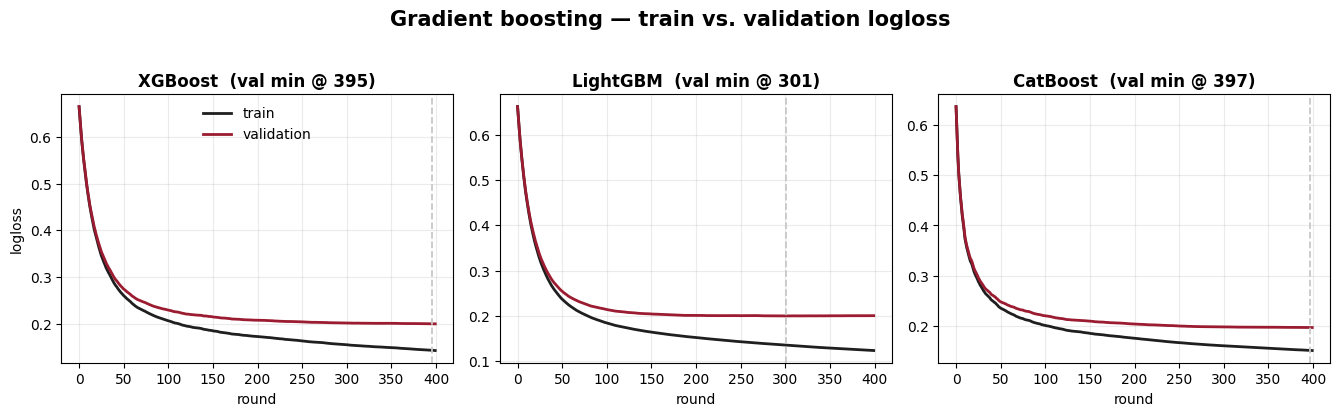

In [9]:
Xtr, Xva, ytr, yva = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
RED, DARK, GREY = "#9B1B30", "#1f1f1f", "#c8c8c8"

xgb = XGBClassifier(n_estimators=400, max_depth=5, learning_rate=0.05, subsample=0.8,
                    colsample_bytree=0.8, reg_lambda=1.0, eval_metric="logloss",
                    scale_pos_weight=spw, random_state=SEED)
xgb.fit(Xtr, ytr, eval_set=[(Xtr, ytr), (Xva, yva)], verbose=False)
xe = xgb.evals_result()

rec = {}
LGBMClassifier(n_estimators=400, num_leaves=31, learning_rate=0.05, min_child_samples=20,
               subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
               class_weight="balanced", random_state=SEED, verbosity=-1).fit(
    Xtr, ytr, eval_set=[(Xtr, ytr), (Xva, yva)], eval_metric="binary_logloss",
    callbacks=[lgb.record_evaluation(rec)])

cat = CatBoostClassifier(iterations=400, depth=6, learning_rate=0.05, l2_leaf_reg=3.0,
                         loss_function="Logloss", eval_metric="Logloss",
                         auto_class_weights="Balanced", random_seed=SEED, verbose=False)
cat.fit(Xtr, ytr, eval_set=(Xva, yva))
ce = cat.get_evals_result()

curves = [("XGBoost", xe["validation_0"]["logloss"], xe["validation_1"]["logloss"]),
          ("LightGBM", rec["training"]["binary_logloss"], rec["valid_1"]["binary_logloss"]),
          ("CatBoost", ce["learn"]["Logloss"], ce["validation"]["Logloss"])]
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))
for ax, (nm, tr, va) in zip(axes, curves):
    ax.plot(tr, color=DARK, lw=2, label="train")
    ax.plot(va, color=RED, lw=2, label="validation")
    bi = int(np.argmin(va)); ax.axvline(bi, color=GREY, ls="--", lw=1.3)
    ax.set_title(f"{nm}  (val min @ {bi})", fontweight="bold"); ax.set_xlabel("round")
    ax.grid(alpha=.25)
    if ax is axes[0]: ax.set_ylabel("logloss"); ax.legend(frameon=False)
fig.suptitle("Gradient boosting — train vs. validation logloss", fontsize=15, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.95))
fig.savefig(FIG / "fig_loss_gbdt.png", dpi=150, bbox_inches="tight")
plt.show()

### TabM — parameter-efficient deep ensembling (BatchEnsemble)

A single MLP that behaves like an ensemble of `k` members: one shared weight
matrix plus a cheap rank-1 adapter `(r_k, s_k)` per member. We tune `k` and the
learning rate, and record the **training cross-entropy + validation AUC per
epoch** for the loss-curve slide.

In [10]:
import torch
import torch.nn as nn
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("TabM device:", DEVICE)


class BatchEnsembleLinear(nn.Module):
    """Shared weight W + per-member rank-1 adapters (r, s) -- BatchEnsemble."""
    def __init__(self, in_f, out_f, k):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(out_f, in_f))
        nn.init.kaiming_uniform_(self.weight, a=5 ** 0.5)
        self.r = nn.Parameter(torch.randint(0, 2, (k, in_f)).float() * 2 - 1)
        self.s = nn.Parameter(torch.randint(0, 2, (k, out_f)).float() * 2 - 1)
        self.bias = nn.Parameter(torch.zeros(k, out_f))

    def forward(self, x):                                   # x: (B, k, in)
        x = x * self.r
        x = torch.einsum("bki,oi->bko", x, self.weight)
        return x * self.s + self.bias


class TabM(nn.Module):
    def __init__(self, n_features, n_classes=2, hidden=256, n_blocks=2, k=32, dropout=0.1):
        super().__init__()
        self.k = k
        dims = [n_features] + [hidden] * n_blocks
        self.layers = nn.ModuleList(
            [BatchEnsembleLinear(dims[i], dims[i + 1], k) for i in range(n_blocks)])
        self.drop = nn.Dropout(dropout)
        self.head = BatchEnsembleLinear(hidden, n_classes, k)

    def forward(self, x):
        x = x.unsqueeze(1).expand(-1, self.k, -1)
        for lyr in self.layers:
            x = self.drop(torch.relu(lyr(x)))
        return self.head(x)

    @torch.no_grad()
    def predict_proba(self, x):
        self.eval()
        return self(x).softmax(-1).mean(1)[:, 1].cpu().numpy()

TabM device: cuda


In [11]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, f1_score, accuracy_score


def fit_tabm(Xtr, ytr, Xval, yval, k=32, hidden=256, dropout=0.1,
             epochs=300, patience=25, lr=1e-3, bs=256):
    """Train one TabM; early-stop on val AUC. Returns model, scaler, train-loss & val-AUC history."""
    sc = StandardScaler().fit(Xtr)
    Xtr_t = torch.tensor(sc.transform(Xtr), dtype=torch.float32, device=DEVICE)
    Xval_t = torch.tensor(sc.transform(Xval), dtype=torch.float32, device=DEVICE)
    ytr_t = torch.tensor(ytr, device=DEVICE)
    model = TabM(Xtr.shape[1], k=k, hidden=hidden, dropout=dropout).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    lossf = nn.CrossEntropyLoss()
    best_auc, best_state, wait = 0.0, None, 0
    loss_hist, auc_hist = [], []
    for ep in range(epochs):
        model.train(); perm = torch.randperm(len(Xtr_t), device=DEVICE); ep_loss = 0.0
        for i in range(0, len(perm), bs):
            idx = perm[i:i + bs]
            logits = model(Xtr_t[idx]); b, kk, C = logits.shape
            loss = lossf(logits.reshape(b * kk, C), ytr_t[idx].repeat_interleave(kk))
            opt.zero_grad(); loss.backward(); opt.step(); ep_loss += loss.item()
        auc = roc_auc_score(yval, model.predict_proba(Xval_t))
        loss_hist.append(ep_loss / (len(perm) // bs + 1)); auc_hist.append(auc)
        if auc > best_auc:
            best_auc, wait = auc, 0
            best_state = {n: p.detach().clone() for n, p in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                break
    model.load_state_dict(best_state)
    return model, sc, best_auc, loss_hist, auc_hist


def tabm_cv(k=32, hidden=256, dropout=0.1, lr=1e-3):
    auc, f1, acc, last = [], [], [], None
    for tr, va in cv.split(X, y):
        Xin, Xes, yin, yes = train_test_split(
            X[tr], y[tr], test_size=0.2, stratify=y[tr], random_state=SEED)
        model, sc, _, lh, ah = fit_tabm(Xin, yin, Xes, yes, k=k, hidden=hidden,
                                        dropout=dropout, lr=lr)
        Xva_t = torch.tensor(sc.transform(X[va]), dtype=torch.float32, device=DEVICE)
        p = model.predict_proba(Xva_t); pred = (p >= 0.5).astype(int)
        auc.append(roc_auc_score(y[va], p)); f1.append(f1_score(y[va], pred))
        acc.append(accuracy_score(y[va], pred)); last = (lh, ah)
    return np.mean(acc), np.mean(f1), np.mean(auc), last


# small grid (TabM is the slow model -- keep it compact)
tabm_rows, tabm_hist = [], None
for k, lr in [(16, 1e-3), (32, 1e-3), (32, 2e-3), (64, 1e-3)]:
    t0 = time.time(); acc, f1, auc, last = tabm_cv(k=k, lr=lr)
    tabm_rows.append({"k": k, "learning_rate": lr, "Accuracy": acc,
                      "F1-Score": f1, "ROC-AUC": auc})
    if auc >= max(r["ROC-AUC"] for r in tabm_rows):
        tabm_hist = last
    print(f"  TabM k={k} lr={lr} -> AUC {auc:.4f}  ({time.time()-t0:.0f}s)")

tab = pd.DataFrame(tabm_rows).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
display(tab.round(4))
b = tab.iloc[0].to_dict()
sweeps["TabM"] = sorted({r["k"]: r["ROC-AUC"] for r in tabm_rows}.items())
tuning_leaderboard.append({"Model": "TabM", "Accuracy": b["Accuracy"],
                           "F1-Score": b["F1-Score"], "ROC-AUC": b["ROC-AUC"]})

  TabM k=16 lr=0.001 -> AUC 0.9794  (11s)
  TabM k=32 lr=0.001 -> AUC 0.9797  (22s)
  TabM k=32 lr=0.002 -> AUC 0.9797  (17s)
  TabM k=64 lr=0.001 -> AUC 0.9798  (54s)


,k,learning_rate,Accuracy,F1-Score,ROC-AUC
0,64,0.001,0.9207,0.9246,0.9798
1,32,0.001,0.9213,0.9249,0.9797
2,32,0.002,0.9217,0.9255,0.9797
3,16,0.001,0.9200,0.9236,0.9794


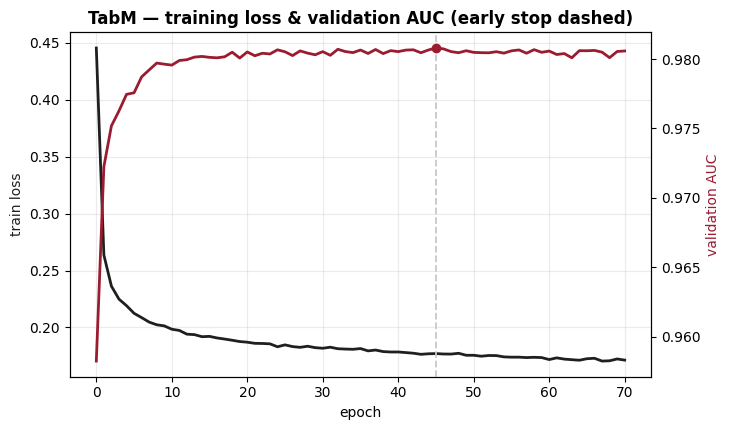

In [12]:
# TabM loss curve: training cross-entropy + validation AUC per epoch (best config)
lh, ah = tabm_hist
fig, ax1 = plt.subplots(figsize=(7.4, 4.4))
ax1.plot(lh, color=DARK, lw=2, label="train cross-entropy")
ax1.set_xlabel("epoch"); ax1.set_ylabel("train loss", color=DARK)
ax2 = ax1.twinx()
ax2.plot(ah, color=RED, lw=2, label="validation AUC")
ax2.set_ylabel("validation AUC", color=RED)
bi = int(np.argmax(ah)); ax2.axvline(bi, color=GREY, ls="--", lw=1.3)
ax2.scatter([bi], [ah[bi]], color=RED, zorder=5)
ax1.set_title("TabM — training loss & validation AUC (early stop dashed)", fontweight="bold")
ax1.grid(alpha=.25)
fig.tight_layout(); fig.savefig(FIG / "fig_loss_tabm.png", dpi=150, bbox_inches="tight")
plt.show()

### TabPFN — in-context learning (zero-tuning baseline)

TabPFN's selling point is that it needs **no tuning** — a single forward pass.
So instead of a grid we run it once under the same CV (optionally varying the
ensemble size `n_estimators` as a light robustness check). Requires
`TABPFN_TOKEN`/GPU; the cell skips cleanly otherwise.

In [13]:
import os
try:
    from dotenv import load_dotenv
    load_dotenv(Path("notebooks") / ".env"); load_dotenv()
except Exception:
    pass

try:
    from tabpfn import TabPFNClassifier
    dev = "cuda" if torch.cuda.is_available() else "cpu"

    def tabpfn_cv(n_estimators=4):
        auc, f1, acc = [], [], []
        for tr, va in cv.split(X, y):
            m = TabPFNClassifier(device=dev, n_estimators=n_estimators,
                                 ignore_pretraining_limits=True, random_state=SEED)
            m.fit(X[tr], y[tr]); p = m.predict_proba(X[va])[:, 1]
            pred = (p >= 0.5).astype(int)
            auc.append(roc_auc_score(y[va], p)); f1.append(f1_score(y[va], pred))
            acc.append(accuracy_score(y[va], pred))
        return np.mean(acc), np.mean(f1), np.mean(auc)

    rows = []
    for ne in (4, 8):
        t0 = time.time(); acc, f1, auc = tabpfn_cv(ne)
        rows.append({"n_estimators": ne, "Accuracy": acc, "F1-Score": f1, "ROC-AUC": auc})
        print(f"  TabPFN n_estimators={ne} -> AUC {auc:.4f}  ({time.time()-t0:.0f}s)")
    tab = pd.DataFrame(rows).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
    display(tab.round(4)); b = tab.iloc[0].to_dict()
    tuning_leaderboard.append({"Model": "TabPFN", "Accuracy": b["Accuracy"],
                               "F1-Score": b["F1-Score"], "ROC-AUC": b["ROC-AUC"]})
except Exception as e:
    print("TabPFN skipped:", e)
    print("Using the Phase-7 result so the leaderboard stays complete.")
    tuning_leaderboard.append({"Model": "TabPFN", "Accuracy": 0.9241,
                               "F1-Score": 0.9275, "ROC-AUC": 0.9810})

  TabPFN n_estimators=4 -> AUC 0.9809  (18s)
  TabPFN n_estimators=8 -> AUC 0.9810  (33s)


,n_estimators,Accuracy,F1-Score,ROC-AUC
0,8,0.9241,0.9275,0.9810
1,4,0.9235,0.9269,0.9809


### Final leaderboard + exports

Promote the best config of every model into one table, then write
`tuning_results.csv`, the LaTeX fragment `leaderboard_table.tex` (paste into the
deck), and the hyperparameter-search panel `figures/fig_tuning_panel.png`.

=== FINAL LEADERBOARD (best config per model) ===


,Model,Accuracy,F1-Score,ROC-AUC
0,TabPFN,0.9241,0.9275,0.9810
1,TabM,0.9207,0.9246,0.9798
2,CatBoost,0.9211,0.9243,0.9796
3,XGBoost,0.9195,0.9227,0.9784
4,LightGBM,0.9185,0.9218,0.9783
5,Random Forest,0.9172,0.9207,0.9768
6,AdaBoost,0.8668,0.8698,0.9536
7,Logistic Regression,0.8643,0.8688,0.9473



wrote tuning_results.csv and leaderboard_table.tex


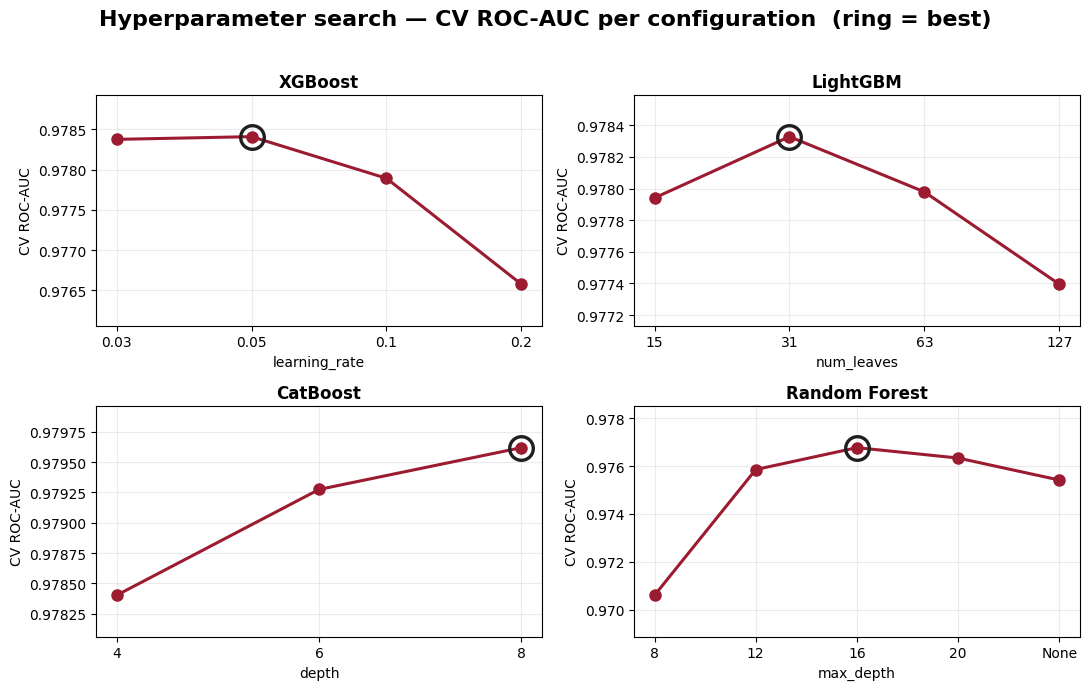

In [14]:
lb = (pd.DataFrame(tuning_leaderboard)
      .drop_duplicates("Model", keep="last")
      .sort_values("ROC-AUC", ascending=False).reset_index(drop=True))
print("=== FINAL LEADERBOARD (best config per model) ===")
display(lb.round(4))
lb.round(4).to_csv("tuning_results.csv", index=False)

# LaTeX fragment (booktabs rows), top row highlighted
lines = []
for i, r in lb.iterrows():
    pre = "\\rowcolor{accent!18}" if i == 0 else ""
    nm = ("\\textbf{%s}" % r["Model"]) if i == 0 else r["Model"]
    lines.append(f"{pre}{nm} & {r['Accuracy']:.4f} & {r['F1-Score']:.4f} & {r['ROC-AUC']:.4f} \\\\")
Path("leaderboard_table.tex").write_text("\n".join(lines))
print("\nwrote tuning_results.csv and leaderboard_table.tex")

# hyperparameter search panel (tree models with a usable sweep)
panel = [m for m in ("XGBoost", "LightGBM", "CatBoost", "Random Forest") if m in sweeps]
keylab = {"XGBoost": "learning_rate", "LightGBM": "num_leaves",
          "CatBoost": "depth", "Random Forest": "max_depth"}
fig, axes = plt.subplots(2, 2, figsize=(11, 7))
for ax, nm in zip(axes.ravel(), panel):
    xs0, ys = zip(*sweeps[nm]); xs = ["None" if v is None else v for v in xs0]
    ax.plot(range(len(xs)), ys, "-o", color=RED, lw=2.2, ms=8)
    bi = int(np.argmax(ys)); ax.plot(bi, ys[bi], "o", ms=17, mfc="none", mec=DARK, mew=2.4)
    ax.margins(y=0.28)
    ax.set_xticks(range(len(xs))); ax.set_xticklabels(xs)
    ax.set_title(nm, fontweight="bold"); ax.set_xlabel(keylab[nm]); ax.set_ylabel("CV ROC-AUC")
    ax.grid(alpha=.25)
fig.suptitle("Hyperparameter search — CV ROC-AUC per configuration  (ring = best)",
             fontsize=16, fontweight="bold")
fig.tight_layout(rect=(0, 0, 1, 0.96))
fig.savefig(FIG / "fig_tuning_panel.png", dpi=150, bbox_inches="tight")
plt.show()